In [5]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

In [6]:
import os
os.chdir('c:\\Users\\Mikael Huff\\Documents\\Training')
os.getcwd()

'c:\\Users\\Mikael Huff\\Documents\\Training'

In [7]:
dataset_train = pd.read_csv('data/TSLA.csv')

In [8]:
dataset_train

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800000,5.000000,3.508000,4.778000,4.778000,93831500
1,2010-06-30,5.158000,6.084000,4.660000,4.766000,4.766000,85935500
2,2010-07-01,5.000000,5.184000,4.054000,4.392000,4.392000,41094000
3,2010-07-02,4.600000,4.620000,3.742000,3.840000,3.840000,25699000
4,2010-07-06,4.000000,4.000000,3.166000,3.222000,3.222000,34334500
...,...,...,...,...,...,...,...
2951,2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500
2952,2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200
2953,2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500
2954,2022-03-23,979.940002,1040.699951,976.400024,999.109985,999.109985,40225400


In [9]:
trainset = dataset_train.iloc[:,1:2].values

In [10]:
trainset

array([[   3.8     ],
       [   5.158   ],
       [   5.      ],
       ...,
       [ 930.      ],
       [ 979.940002],
       [1009.72998 ]], shape=(2956, 1))

In [ ]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0,1))
training_scaled = sc.fit_transform(trainset)


In [53]:
N=len(training_scaled)
training_scaled


array([[4.64594174e-04],
       [1.56759922e-03],
       [1.43926727e-03],
       ...,
       [7.52749776e-01],
       [7.93312423e-01],
       [8.17508664e-01]], shape=(2956, 1))

In [54]:
x_train = []
y_train = []
for i in range(60,N):
    x_train.append(training_scaled[i-60:i, 0])
    y_train.append(training_scaled[i,0])
x_train,y_train = np.array(x_train),np.array(y_train)
# print(x_train)
# y_train.shape

In [55]:
dur = 60
x_idx = np.arange(N-dur) + np.arange(dur)[:,None]
x_train2 = np.squeeze(training_scaled[x_idx.transpose()])
y_train2= np.squeeze(training_scaled[np.arange(dur, N)    ])
# print(np.array_equal(y_train,y_train2))
# print(np.array_equal(x_train,x_train2))
# print(x_test)
y_train.shape

True
True


(2896,)

In [56]:
x_train.shape

(2896, 60)

In [63]:
split = int(N *.8)
x_test = x_train[split+1:]
y_test = y_train[split+1:]
x_train = x_train[:split]
y_train = y_train[:split]

In [64]:
x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

In [65]:
x_train.shape

(2364, 60, 1)

In [66]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import SimpleRNN
from keras.layers import Dropout

In [67]:
regressor = Sequential()
regressor.add(SimpleRNN(units = 50,return_sequences = True,input_shape = (x_train.shape[1],1)))

c:\Users\Mikael Huff\Documents\Training\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [68]:
regressor.add(Dropout(0.2))

In [69]:
regressor.add(SimpleRNN(units = 50,return_sequences = True))
regressor.add(Dropout(0.2))

In [70]:
regressor.add(SimpleRNN(units = 50))
regressor.add(Dropout(0.2))

In [73]:
regressor.add(Dense(units = 1))

In [74]:
regressor.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 60, 50)         │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,753 (49.82 KB)

 Trainable params: 12,753 (49.82 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
regressor.compile(optimizer = 'adam',loss = 'mean_squared_error')

In [76]:
regressor.fit(x_train,y_train,epochs = 100, batch_size = 32)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0038
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 2.4056e-04
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 1.5638e-04
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 1.1297e-04
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 8.5215e-05
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 7.2915e-05
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 6.4364e-05
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 5.7463e-05
Epoch 9/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 5.0858e-05
Epoch 10/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 4.6026e-05
Epoch 11/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 4.1236e-05
Epoch 12/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 4.2447e-05
Epoch 13/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 3.6351e-05
Epoch 14/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 3.1154e-05
Epoch

In [90]:
# dataset_test =pd.read_csv("testset.csv")
dataset_test = dataset_train[split+1:]
real_stock_price = dataset_test.iloc[:,1:2].values
real_stock_price.shape

(591, 1)

In [78]:
dataset_total = pd.concat((dataset_train['Open'],dataset_test['Open']),axis = 0)
dataset_total

0          3.800000
1          5.158000
2          5.000000
3          4.600000
4          4.000000
           ...     
2951     874.489990
2952     914.979980
2953     930.000000
2954     979.940002
2955    1009.729980
Name: Open, Length: 3547, dtype: float64

In [79]:
inputs = dataset_total[len(dataset_total) - len(dataset_test)-60:].values
inputs

array([1098.640015, 1061.329956, 1073.439941, 1147.75    , 1189.550049,
       1146.650024, 1077.      , 1080.369995, 1000.      , 1053.670044,
       1078.849976, 1109.069946, 1019.880005, 1026.609985, 1041.709961,
       1009.72998 ,  996.340027,  904.76001 ,  914.200012,  952.429993,
        933.359985,  831.559998,  872.710022,  935.210022,  928.179993,
        882.      ,  897.219971,  923.789978,  905.530029,  935.      ,
        908.369995,  909.630005,  861.570007,  900.      ,  914.049988,
        913.26001 ,  886.      ,  834.130005,  830.429993,  700.390015,
        809.22998 ,  815.01001 ,  869.679993,  872.130005,  878.77002 ,
        849.099976,  856.299988,  795.530029,  839.47998 ,  851.450012,
        840.200012,  780.609985,  775.27002 ,  809.      ,  830.98999 ,
        874.48999 ,  914.97998 ,  930.      ,  979.940002, 1009.72998 ,
         70.349998,   72.      ,   70.902   ,   68.031998,   68.863998,
         67.054001,   66.223999,   66.222   ,   65.879997,   66.

In [80]:
inputs = inputs.reshape(-1,1)

In [81]:
inputs

array([[1098.640015],
       [1061.329956],
       [1073.439941],
       [1147.75    ],
       [1189.550049],
       [1146.650024],
       [1077.      ],
       [1080.369995],
       [1000.      ],
       [1053.670044],
       [1078.849976],
       [1109.069946],
       [1019.880005],
       [1026.609985],
       [1041.709961],
       [1009.72998 ],
       [ 996.340027],
       [ 904.76001 ],
       [ 914.200012],
       [ 952.429993],
       [ 933.359985],
       [ 831.559998],
       [ 872.710022],
       [ 935.210022],
       [ 928.179993],
       [ 882.      ],
       [ 897.219971],
       [ 923.789978],
       [ 905.530029],
       [ 935.      ],
       [ 908.369995],
       [ 909.630005],
       [ 861.570007],
       [ 900.      ],
       [ 914.049988],
       [ 913.26001 ],
       [ 886.      ],
       [ 834.130005],
       [ 830.429993],
       [ 700.390015],
       [ 809.22998 ],
       [ 815.01001 ],
       [ 869.679993],
       [ 872.130005],
       [ 878.77002 ],
       [ 8

In [82]:
inputs = sc.transform(inputs)
inputs.shape

(651, 1)

In [94]:
x_test = []
for i in range(dur, int(N*.2)):
    x_test.append(inputs[i-60:i,0])

In [95]:
# dataset_test.shape
# int(N*.2)

In [96]:
x_test = np.array(x_test)
x_test.shape

(531, 60)

In [97]:
x_test = np.reshape(x_test, (x_test.shape[0],x_test.shape[1],1))
x_test.shape

(531, 60, 1)

In [98]:
predicted_price = regressor.predict(x_test)

 1/17 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [99]:
predicted_price = sc.inverse_transform(predicted_price)
predicted_price.shape

(531, 1)

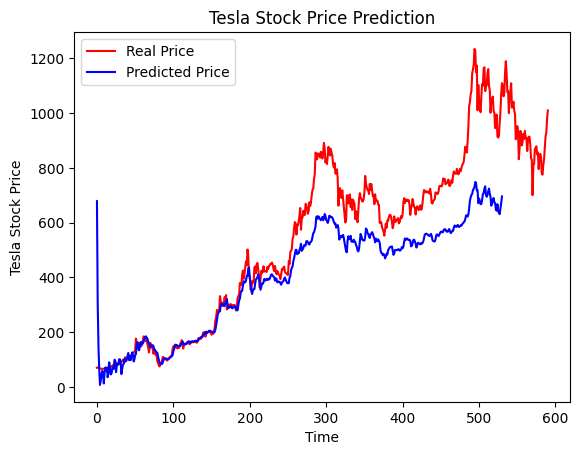

In [100]:
plt.plot(real_stock_price,color = 'red', label = 'Real Price')
plt.plot(predicted_price, color = 'blue', label = 'Predicted Price')
plt.title('Tesla Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Tesla Stock Price')
plt.legend()
plt.show()